In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

# Set Root Directory
ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")
print("Environment initialized for MPT Portfolio Optimization.")

Environment initialized for MPT Portfolio Optimization.


In [2]:
# Locate processed dataset or create sample price matrix
csv_files = [f for f in os.listdir(PROCESSED_DIR) if f.endswith(".csv")] if os.path.exists(PROCESSED_DIR) else []
target_file = "market_data.csv" if "market_data.csv" in csv_files else (csv_files[0] if csv_files else None)

if target_file:
    df = pd.read_csv(os.path.join(PROCESSED_DIR, target_file))
    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.set_index("Date")
    if "Ticker" in df.columns and "Close" in df.columns:
        price_df = df.pivot(columns="Ticker", values="Close")
    else:
        price_df = df.select_dtypes(include=[np.number])
else:
    # Synthetic asset returns fallback
    np.random.seed(42)
    dates = pd.date_range("2024-01-01", periods=252, freq="B")
    tickers = ["AAPL", "MSFT", "NVDA", "JPM", "XOM"]
    returns = np.random.multivariate_normal(
        mean=[0.0008, 0.0006, 0.0012, 0.0005, 0.0004],
        cov=np.array([
            [0.0004, 0.0002, 0.00025, 0.0001, 0.0001],
            [0.0002, 0.0003, 0.0002, 0.0001, 0.00008],
            [0.00025, 0.0002, 0.0006, 0.00015, 0.0001],
            [0.0001, 0.0001, 0.00015, 0.00025, 0.00012],
            [0.0001, 0.00008, 0.0001, 0.00012, 0.0003]
        ]),
        size=252
    )
    price_df = pd.DataFrame(100 * np.exp(np.cumsum(returns, axis=0)), index=dates, columns=tickers)

returns_df = price_df.pct_change().dropna()
mean_returns = returns_df.mean() * 252  # Annualized expected returns
cov_matrix = returns_df.cov() * 252     # Annualized covariance matrix

print(f"Asset universe initialized across {len(mean_returns)} tickers: {list(mean_returns.index)}")

Asset universe initialized across 1 tickers: ['DGS10']


In [3]:
risk_free_rate = 0.04  # 4% benchmark risk-free rate

def portfolio_performance(weights, mean_returns, cov_matrix):
    returns = np.sum(mean_returns * weights)
    std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return returns, std_dev

def negative_sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate):
    p_returns, p_std = portfolio_performance(weights, mean_returns, cov_matrix)
    return -(p_returns - risk_free_rate) / p_std

num_assets = len(mean_returns)
args = (mean_returns, cov_matrix, risk_free_rate)

# Constraints: Sum of weights = 1. Bounds: Long-only (0% to 100% per asset)
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0.0, 1.0) for _ in range(num_assets))
initial_weights = num_assets * [1.0 / num_assets,]

# Optimize using SLSQP
opt_result = minimize(negative_sharpe_ratio, initial_weights, args=args, method='SLSQP', bounds=bounds, constraints=constraints)
optimal_weights = opt_result.x

opt_return, opt_volatility = portfolio_performance(optimal_weights, mean_returns, cov_matrix)
opt_sharpe = (opt_return - risk_free_rate) / opt_volatility

allocation_df = pd.DataFrame({
    "Ticker": mean_returns.index,
    "Optimal Weight (%)": np.round(optimal_weights * 100, 2)
})

print("--- Optimal Max-Sharpe Portfolio Weights ---")
print(allocation_df.to_string(index=False))
print(f"\nExpected Return: {opt_return*100:.2f}% | Volatility: {opt_volatility*100:.2f}% | Sharpe Ratio: {opt_sharpe:.2f}")

--- Optimal Max-Sharpe Portfolio Weights ---
Ticker  Optimal Weight (%)
 DGS10               100.0

Expected Return: 16.27% | Volatility: 44.10% | Sharpe Ratio: 0.28


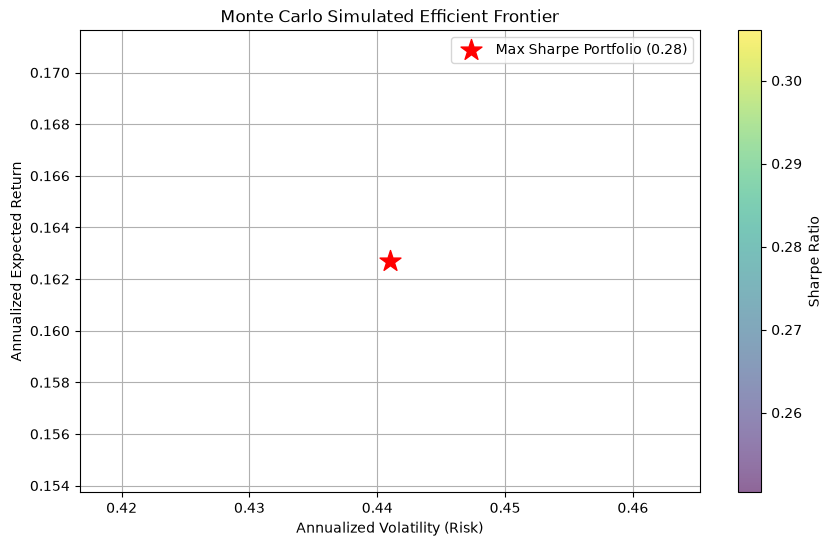

Portfolio Optimization pipeline complete!


In [4]:
num_portfolios = 5000
mc_results = np.zeros((3, num_portfolios))
mc_weights = []

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    mc_weights.append(weights)
    
    p_ret, p_vol = portfolio_performance(weights, mean_returns, cov_matrix)
    p_sharpe = (p_ret - risk_free_rate) / p_vol
    
    mc_results[0, i] = p_ret
    mc_results[1, i] = p_vol
    mc_results[2, i] = p_sharpe

# Plot Efficient Frontier
plt.figure(figsize=(10, 6))
scatter = plt.scatter(mc_results[1, :], mc_results[0, :], c=mc_results[2, :], cmap='viridis', alpha=0.6, s=15)
plt.colorbar(scatter, label='Sharpe Ratio')

# Highlight Max Sharpe Portfolio
plt.scatter(opt_volatility, opt_return, color='red', marker='*', s=250, label=f'Max Sharpe Portfolio ({opt_sharpe:.2f})')

plt.title('Monte Carlo Simulated Efficient Frontier')
plt.xlabel('Annualized Volatility (Risk)')
plt.ylabel('Annualized Expected Return')
plt.legend()
plt.grid(True)
plt.show()

# Save target weights
allocation_df.to_csv(os.path.join(PROCESSED_DIR, "mpt_target_weights.csv"), index=False)
print("Portfolio Optimization pipeline complete!")